In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


# loading assignment and chat datasets


assignments  = pd.read_csv('/content/drive/MyDrive/AI gp project/assignments_dataset_1.csv')
chat         = pd.read_csv('/content/drive/MyDrive/AI gp project/chat_interaction_dataset.csv')


print(f"  assignments  : {assignments.shape}")
print(f"  chat         : {chat.shape}")

  assignments  : (200, 7)
  chat         : (100, 2)


In [6]:
# 1. Handling any missing values  (none found, but verified)

print("=" * 60)
print("STEP 1 - CHECK FOR MISSING VALUES:")
print("=" * 60)

for name, df in [("assignments", assignments),
                  ("chat", chat)]:
    total_null = df.isnull().sum().sum()
    print(f"  {name:<15}: {total_null} missing values → {'OK' if total_null == 0 else 'NEEDS FILL'}")


#------------------------------------------------
# 2. Remove any duplicates
print("=" * 60)
print("STEP 2 - REMOVE DUPLICATES: ")
print("=" * 60)

#Keep only unique query-response PAIRS (not just unique rows)
# for chat dataset: removed true duplicates but kept all unique combinations
before = len(chat)
chat = chat.drop_duplicates(subset=['query', 'response']).reset_index(drop=True)
after = len(chat)
print(f"  chat         : removed {before - after} duplicates ({before} → {after} rows)")



for name, df in [("assignments", assignments)]:
    dups = df.duplicated().sum()
    print(f"  {name:<15}: {dups} duplicates → OK")




#------------------------------------------------------
# 3. Formatting date fields to one format
print("=" * 60)
print("STEP 3 - DATE FORMAT STANDARDISATION")
print("=" * 60)


assignments['due_date'] = pd.to_datetime(assignments['due_date'], dayfirst=True)

print(f"  assignments due_date : {assignments['due_date'].dtype} | sample: {assignments['due_date'].iloc[0].date()}")

#----------------------------------------------------------------------------
# 4. Standarding for categorical/text values
print("=" * 60)
print("STEP 4 - TEXT STANDARDISATION: ")
print("=" * 60)


# Trim whitespace and title-case all categorical string columns
str_cols = {
    'assignments': ['assignment_name', 'course', 'difficulty'],
    'chat':        ['query', 'response'],
}

for df_name, cols in str_cols.items():
    df = eval(df_name)
    for col in cols:
        df[col] = df[col].str.strip()
    print(f"  {df_name:<15}: stripped whitespace on {cols}")


#-----------------------------------------------------------------
# 5. Feature Engineering
print("=" * 60)
print("STEP 5 - FEATURE ENGINEERING:")
print("=" * 60)

REFERENCE_DATE = pd.Timestamp('2026-03-16')

# 5a. assignments: days_until_due, urgency_score, points_per_hour
assignments['days_until_due'] = (assignments['due_date'] - REFERENCE_DATE).dt.days
assignments['urgency_score']  = (
    (1 / (assignments['days_until_due'].clip(lower=1))) *
    assignments['estimated_hours']
).round(4)
assignments['points_per_hour'] = (assignments['points'] / assignments['estimated_hours']).round(2)
print("  assignments  : + days_until_due, urgency_score, points_per_hour")

#----------------------------------------------------------------------
# 6. Label Encoding for ordinal/norminal values
print("=" * 60)
print("STEP 6 - LABEL ENCODING: ")
print("=" * 60)

le = LabelEncoder()

# difficulty: Low=0, Medium=1, High=2 (ordinal — preserve order)
diff_order = {'Low': 0, 'Medium': 1, 'High': 2}
assignments['difficulty_encoded'] = assignments['difficulty'].map(diff_order)
print(f"  difficulty (ordinal)        : {diff_order}")

#--------------------------------------------------------------------------------
# 7. Norminalization (MinMaxScaler on numeric features)
print("=" * 60)
print("STEP 7 - NORMALISATION (Min-Max Scaling): ")
print("=" * 60)

scaler = MinMaxScaler()

# assignments numeric cols
asgn_num_cols = ['estimated_hours', 'points', 'days_until_due', 'urgency_score', 'points_per_hour']
assignments[asgn_num_cols] = scaler.fit_transform(assignments[asgn_num_cols])
print(f"  assignments  : scaled {asgn_num_cols}")

STEP 1 - CHECK FOR MISSING VALUES:
  assignments    : 0 missing values → OK
  chat           : 0 missing values → OK
STEP 2 - REMOVE DUPLICATES: 
  chat         : removed 77 duplicates (100 → 23 rows)
  assignments    : 0 duplicates → OK
STEP 3 - DATE FORMAT STANDARDISATION
  assignments due_date : datetime64[ns] | sample: 2026-03-23
STEP 4 - TEXT STANDARDISATION: 
  assignments    : stripped whitespace on ['assignment_name', 'course', 'difficulty']
  chat           : stripped whitespace on ['query', 'response']
STEP 5 - FEATURE ENGINEERING:
  assignments  : + days_until_due, urgency_score, points_per_hour
STEP 6 - LABEL ENCODING: 
  difficulty (ordinal)        : {'Low': 0, 'Medium': 1, 'High': 2}
STEP 7 - NORMALISATION (Min-Max Scaling): 
  assignments  : scaled ['estimated_hours', 'points', 'days_until_due', 'urgency_score', 'points_per_hour']


In [7]:
# Save cleaned datasets

assignments.to_csv("assignments_cleaned.csv", index=False)
chat.to_csv("chat_cleaned.csv", index=False)

In [ ]:
#download files
from google.colab import files

files.download("assignments_cleaned.csv")
files.download("chat_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
#8. Creating target variable
print("=" * 60)
print("STEP 8 - TARGET VARIABLE CREATION")
print("=" * 60)

#8a. Create balanced priority classes from urgency_score
# Using quantiles ensures roughly equal distribution of Low, Medium, High

assignments['priority'] = pd.qcut(
    assignments['urgency_score'],
    q=3,
    labels=[0,1,2]  # 0 = Low, 1 = Medium, 2 = High
)

assignments['priority'] = assignments['priority'].astype(int)

print("Priority classes created using urgency_score quantiles")
print(assignments[['urgency_score','priority']].head())

print("\nClass distribution:")
print(assignments['priority'].value_counts())


#9. Select features
print("\n")
print("=" * 60)
print("STEP 9 - FEATURE SELECTION")
print("=" * 60)

#9a. Check available columns first
print("Available columns:")
print(assignments.columns)

#9b. Define features safely
# Note: urgency_score removed to avoid data leakage
feature_cols = [
    'days_until_due',
    'points_per_hour',
    'estimated_hours',
    'points',
    'difficulty_encoded',
    'course_encoded'
]

#9c. Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in assignments.columns]

print("Features selected:", feature_cols)

X = assignments[feature_cols]
y = assignments['priority']


#10. Train/Test Split
print("\n")
print("=" * 60)
print("STEP 10 - TRAIN/TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Test split completed")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


#11. Train XGBoost Model
print("\n")
print("=" * 60)
print("STEP 11 - TRAIN XGBOOST MODEL")
print("=" * 60)

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully")


#12. Make Predictions
print("\n")
print("=" * 60)
print("STEP 12 - PREDICTIONS")
print("=" * 60)

y_pred = model.predict(X_test)

print("Predictions completed")
print("Sample predictions:")
print(y_pred[:10])



STEP 8 - TARGET VARIABLE CREATION
Priority classes created using urgency_score quantiles
   urgency_score  priority
0       0.031609         2
1       0.013683         1
2       0.017110         1
3       0.005046         0
4       0.015051         1

Class distribution:
priority
0    68
2    67
1    65
Name: count, dtype: int64


STEP 9 - FEATURE SELECTION
Available columns:
Index(['assignment_id', 'assignment_name', 'course', 'due_date', 'difficulty',
       'estimated_hours', 'points', 'days_until_due', 'urgency_score',
       'points_per_hour', 'difficulty_encoded', 'priority'],
      dtype='object')
Features selected: ['days_until_due', 'points_per_hour', 'estimated_hours', 'points', 'difficulty_encoded']


STEP 10 - TRAIN/TEST SPLIT
Train/Test split completed
Training samples: 160
Testing samples : 40


STEP 11 - TRAIN XGBOOST MODEL
XGBoost model trained successfully


STEP 12 - PREDICTIONS
Predictions completed
Sample predictions:
[0 1 0 1 2 2 2 2 1 2]




STEP 13 - MODEL EVALUATION


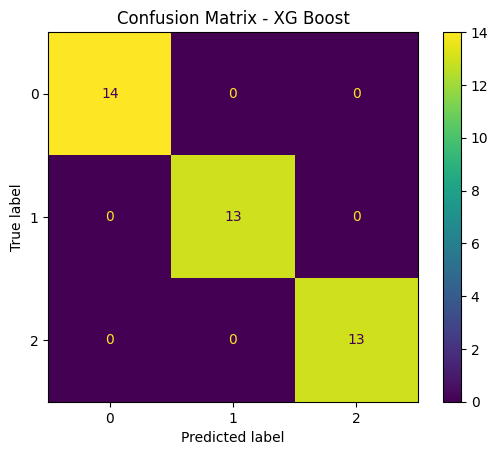

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



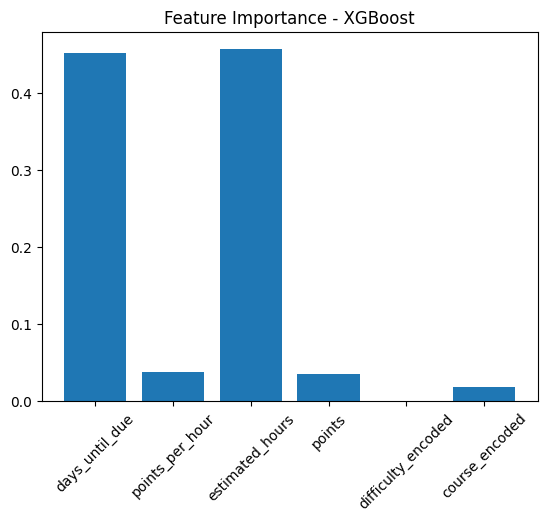

Baseline Accuracy: 0.4
XGBoost Accuracy: 1.0


In [ ]:
#13. Display result
print("\n")
print("=" * 60)
print("STEP 13 - MODEL EVALUATION")
print("=" * 60)


from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

plt.title("Confusion Matrix - XG Boost")
plt.show()


#Display classification report
print(classification_report(y_test, y_pred))

#Display feature importance
feature_importances = model.feature_importances_
plt.bar(X.columns,feature_importances)
plt.xticks(rotation=45)
plt.title("Feature Importance - XGBoost")
plt.show()

# Simple baseline: prioritize based only on days_until_due
baseline_pred = (X_test['days_until_due'] < 0.3).astype(int)

#Performance comparison
print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))



In [ ]:
#14. Save model
print("\n")
print("=" * 60)
print("STEP 14 - SAVE MODEL")
print("=" * 60)

import joblib
joblib.dump(model, 'xgboost_model.pkl')
print("Model saved successfully")



STEP 14 - SAVE MODEL
Model saved successfully
